# Imports

In [1]:
import os
import sys

In [2]:
current_dir =  os.getcwd()
# replace this following line in the path your frank2d files are.
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

In [3]:
parent_dir

'/localhome/home/zgdz996/frank2d'

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [5]:
# frank2d
from frank2d import Frank2D
from frank2d.geometry import Geometry
from frank2d.plot import Plot
from frank2d.posterior_optimization import *
from frank2d.constants import rad_to_arcsec, deg_to_rad
from frank2d.posterior_optimization import MAPEstimator

In [6]:

dir = "./../../data/"
data_file = dir + "uvtable_nonsym_disc_blob_noisy.npz"
inc = 0
pa = 0
dra = 0
ddec = 0
rout = 1*2

# Load data
file = np.load(data_file)
u, v, Vis, Weights = file['u'], file['v'], file['vis'], file['weights']
uvtable = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights }

geom = Geometry(inc, pa, dra, ddec)

## Run frank2d for differents N

In [7]:
routs = [rout/2, (rout/2)*1.5, rout, (rout/2)*2.5, (rout/2)*3, (rout/2)*3.5]

In [8]:
N = 300

In [9]:
frank2d_objects = []

In [10]:
times = []

In [11]:
params_N80 = {'m': -4.572459366888535, 'c': 1.0086866109221515e+24, 'l': 68720.91547274287}

In [12]:
for i in range(len(routs)):
    start = time.time()
    frank2d = Frank2D(N, routs[i])
    frank2d.fit(data = uvtable, kernel_params = params_N80, rtol = 1e-10)

    end = time.time()
    total_time = end - start
    times.append(total_time)
    print(f"xxxxxxxxxxxxxxxxxxxxxxxxx F2D with rout ={routs[i]} took {end - start} seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx")
    frank2d_objects.append(frank2d)


===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -4.572459366888535, 'c': 1.0086866109221515e+24, 'l': 68720.91547274287}
===>  Creating sparse linear system...
        +  Kernel = 0.01  min |  0.46 seconds
        +  Building system = 0.01  min |  0.48 seconds
===>  Solving linear system...
      .... iteration  0 :   actual tol  2.15e+08  versus  2.15e-02
      .... iteration  10 :   actual tol  6.11e+04  versus  2.15e-02
      .... iteration  20 :   actual tol  2.64e+02  versus  2.15e-02
      .... iteration  30 :   actual tol  5.51e-01  versus  2.15e-02
         +  BiCGStab = 0.04  min |  2.35 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of r',
 'final_tol': 0.02151941137358614,
 'iterations': 32,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-10}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.04  min |  2.34 seconds
--> times building ful

KeyboardInterrupt: 

### Complexity plot 

Text(0, 0.5, 'Time (mins)')

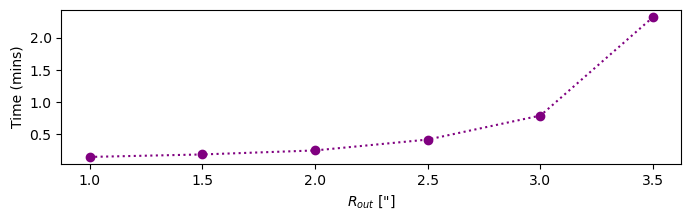

In [ ]:
plt.figure(figsize=(8,2))
plt.plot(routs, np.array(times)/60, marker='o', ls=':', color = 'purple')
plt.xlabel( r'$R_{out}$ ["]', fontsize=10)
plt.ylabel('Time (mins)', fontsize=10)

## Analize differents results

In [ ]:
fluxs = []

xxxxxxxxxxxx Total flux:  [0.20565543]


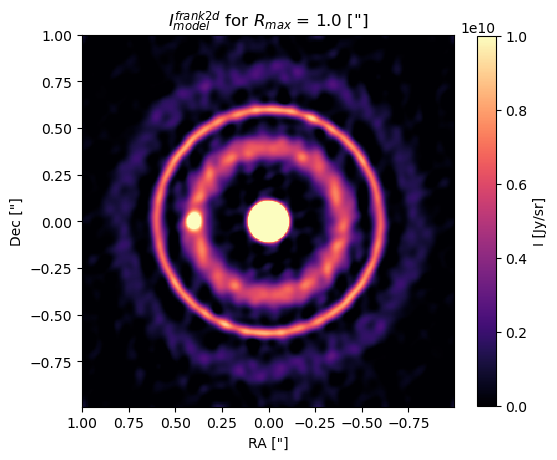

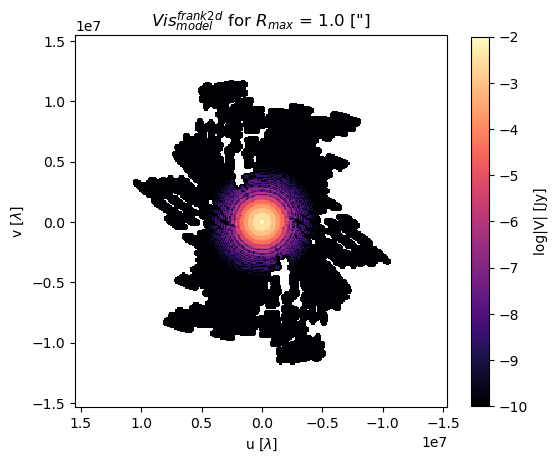

xxxxxxxxxxxx Total flux:  [0.21141686]


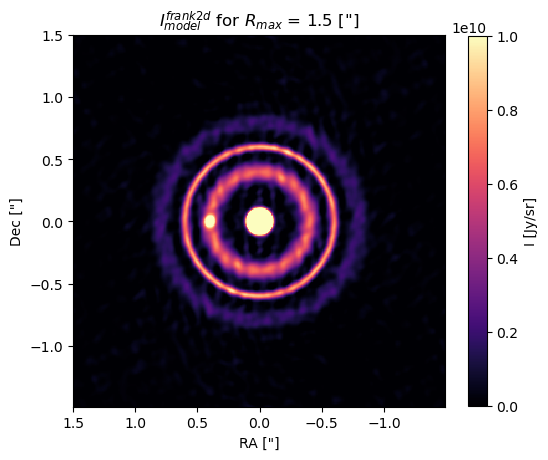

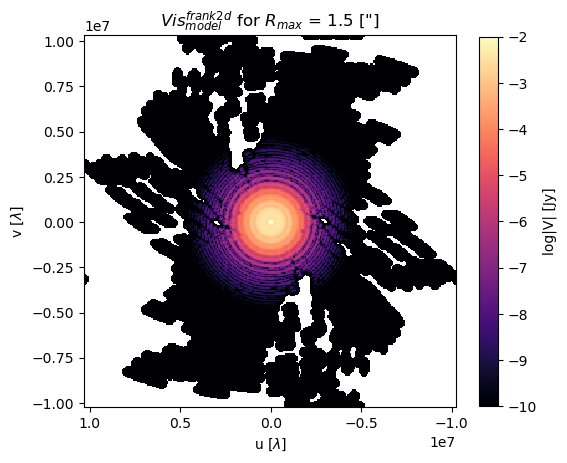

xxxxxxxxxxxx Total flux:  [0.21704024]


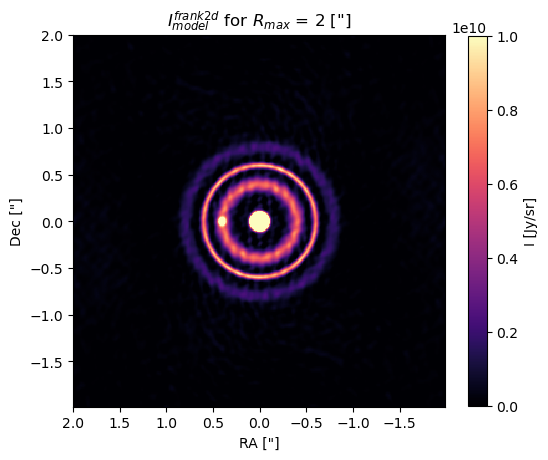

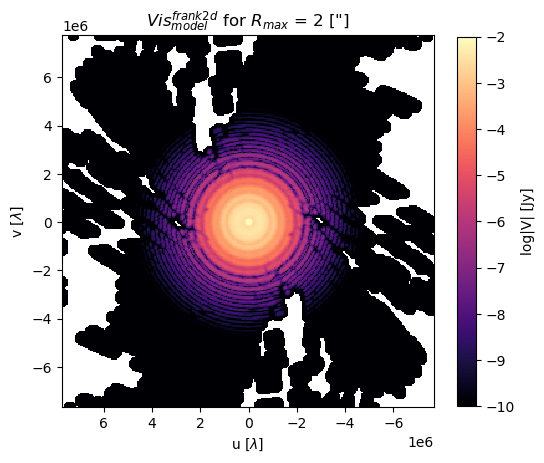

xxxxxxxxxxxx Total flux:  [0.21956948]


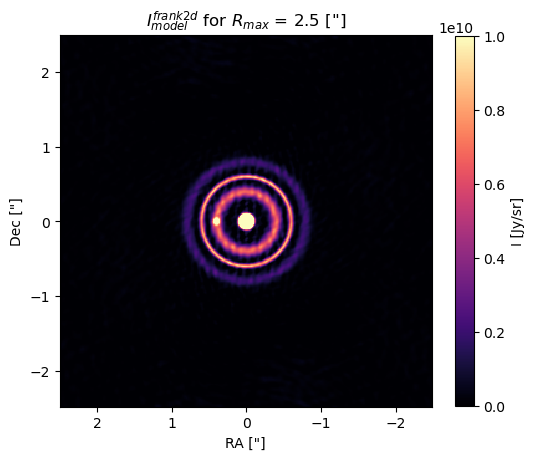

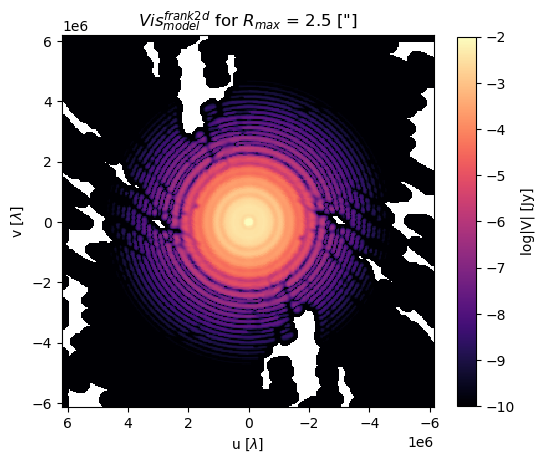

xxxxxxxxxxxx Total flux:  [0.22027666]


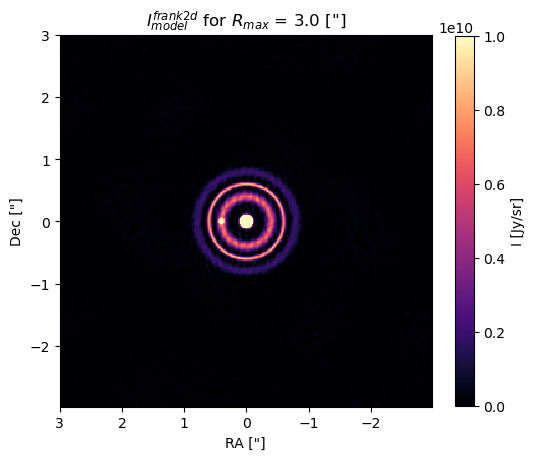

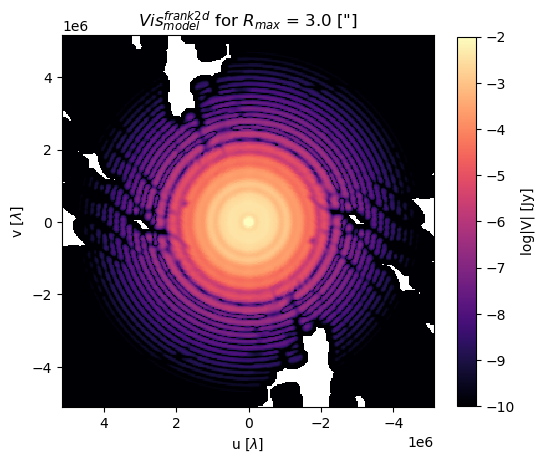

xxxxxxxxxxxx Total flux:  [0.22027666]


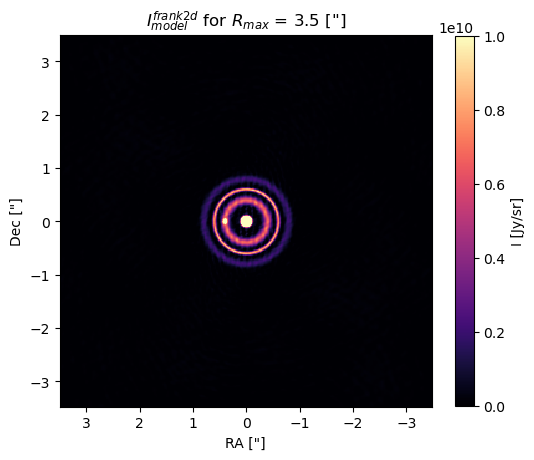

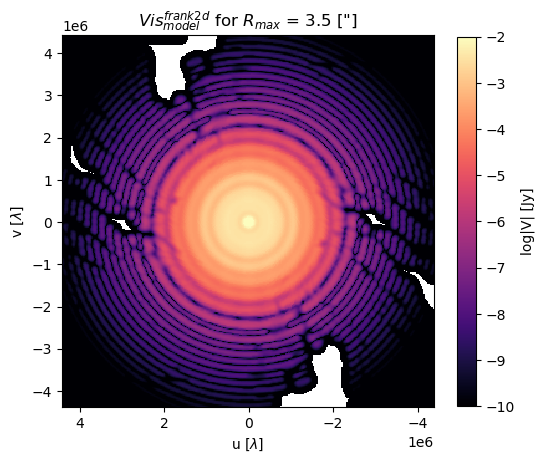

In [ ]:
for i in range(len(routs)):
    Plot_ = Plot(frank2d_objects[i], geom)
    frank2d = frank2d_objects[i]
    u, v = frank2d.u_grid, frank2d.v_grid
    vis = frank2d.visibility_model

    index = np.where((u == 0) & (v == 0))
    V_00 = vis[index].real
    fluxs.append(V_00)
    print("xxxxxxxxxxxx Total flux: ", V_00)
    Plot_.intensity( vmax=1e10,  gamma = 1, zoom=1,
                     title= r'$I_{model}^{frank2d}$ for $R_{max}$ = ' + str(routs[i]) + ' ["]')
    Plot_.visibility(fig_size = 6,
                     title = r'$Vis_{model}^{frank2d}$ for $R_{max}$ = ' + str(routs[i])+ ' ["]')

Text(0, 0.5, 'Total flux [Jy]')

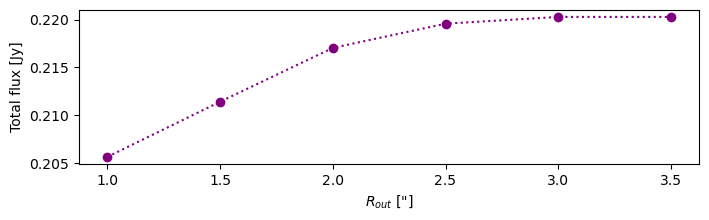

In [ ]:
plt.figure(figsize=(8,2))
plt.plot(routs, fluxs, marker='o', ls=':', color = 'purple')
plt.xlabel( r'$R_{out}$ ["]', fontsize=10)
plt.ylabel('Total flux [Jy]', fontsize=10)